# GOLD GAME CATALOG

## Imports and Load datasets

In [1]:
import pandas as pd
import seaborn as sns

from ecommerce_ingestion.config.constants import (
    DB_OUTPUT_GOLD,
    DB_OUTPUT_SILVER,
)


In [10]:
gold_game_catalog = pd.read_parquet(DB_OUTPUT_SILVER / "silver_cleaned_data.parquet")


data_genre_links =pd.read_parquet(DB_OUTPUT_SILVER / 
                                  "silver_game_genre_relationships.parquet")
data_genre_links["game_id"] = data_genre_links["game_id"].str.strip().str.lower()



In [11]:
gold_game_catalog.shape

(2976, 24)

In [13]:
gold_game_catalog[gold_game_catalog.duplicated(subset=["game_id"], keep=False)]

,game_id,game_source_site,source_game_product_code,game_name,game_product_type,game_rating,game_pdp_url,game_developer,game_description,genres,...,category_url,category_path,category_parent_id,category_level,category_is_leaf,current_price,currency,stock_status,meta_score,user_score
1422,doom ii,oxylabs_sandbox,1423,DOOM II,multiplayer,M,https://www.metacritic.com/game/xbox-360/doom-ii,id software,"[Xbox Live Arcade] To save Earth, you must d...","action, arcade, first-person, sci-fi, shooter",...,https://oxylabs.io/products/category/xbox-plat...,xbox-platform/xbox-360,xbox-platform,2,1,84.99,EUR,in_stock,77,84
1515,doom ii,oxylabs_sandbox,1516,Doom II,multiplayer,T,https://www.metacritic.com/game/game-boy-advan...,torus games,Hell's fury has been unleashed. Billions are d...,"action, first-person, sci-fi, shooter",...,https://oxylabs.io/products/category/nintendo/...,nintendo/game-boy-advance,nintendo,2,1,88.99,EUR,out_of_stock,77,88


## Analize genres

<Axes: xlabel='genre_id', ylabel='Count'>

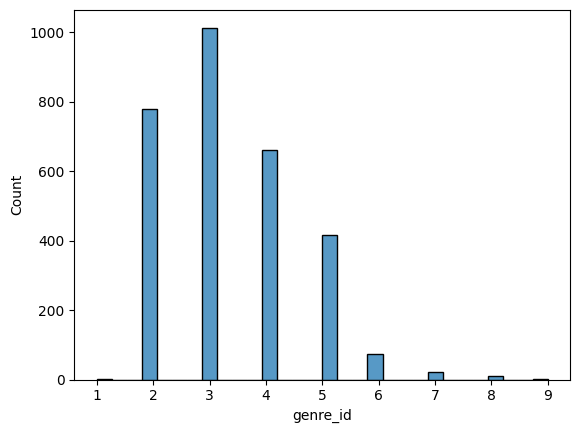

In [51]:
data_genre_compiled = data_genre_links.groupby("game_id").agg({"genre_id": "count"})
data_genre_compiled["genre_id"].unique()
sns.histplot(data_genre_compiled["genre_id"], bins=30)

## Normalize and reduce genre

### Mapper

In [52]:
GENRE_MAPPER = {
    "role-playing": ("rpg", 1),
    "action rpg": ("rpg", 1),
    "console-style rpg": ("rpg", 1),
    "japanese-style": ("rpg", 1),
    "pc-style rpg": ("rpg", 1),
    "western-style": ("rpg", 1),

    "action": ("action", 2),
    "action adventure": ("action", 2),
    "beat-'em-up": ("action", 2),
    "open-world": ("action", 2),
    "survival": ("action", 2),

    "shooter": ("shooter", 3),
    "first-person": ("shooter", 3),
    "third-person": ("shooter", 3),
    "light gun": ("shooter", 3),
    "shoot-'em-up": ("shooter", 3),

    "adventure": ("adventure", 4),
    "point-and-click": ("adventure", 4),
    "visual novel": ("adventure", 4),
    "hidden object": ("adventure", 4),
    "text": ("adventure", 4),

    "strategy": ("strategy", 5),
    "tactics": ("strategy", 5),
    "tactical": ("strategy", 5),
    "turn-based": ("strategy", 5),
    "real-time": ("strategy", 5),
    "4x": ("strategy", 5),
    "wargame": ("strategy", 5),
    "city building": ("strategy", 5),
    "management": ("strategy", 5),
    "business / tycoon": ("strategy", 5),
    "tycoon": ("strategy", 5),
    "defense": ("strategy", 5),

    "simulation": ("simulation", 6),
    "sim": ("simulation", 6),
    "flight": ("simulation", 6),
    "driving": ("simulation", 6),
    "sandbox": ("simulation", 6),
    "virtual life": ("simulation", 6),
    "breeding/constructing": ("simulation", 6),
    "trainer": ("simulation", 6),
    "exercise / fitness": ("simulation", 6),

    "sports": ("sports", 7),
    "soccer": ("sports", 7),
    "football": ("sports", 7),
    "basketball": ("sports", 7),
    "tennis": ("sports", 7),
    "golf": ("sports", 7),
    "baseball": ("sports", 7),
    "ice hockey": ("sports", 7),
    "cricket": ("sports", 7),
    "boxing": ("sports", 7),
    "boxing / martial arts": ("sports", 7),
    "wrestling": ("sports", 7),
    "skateboarding": ("sports", 7),
    "skate / skateboard": ("sports", 7),
    "skiing": ("sports", 7),
    "ski / snowboard": ("sports", 7),
    "snowboarding": ("sports", 7),
    "surfing": ("sports", 7),
    "fishing": ("sports", 7),
    "olympic sports": ("sports", 7),
    "athletics": ("sports", 7),
    "volleyball": ("sports", 7),

    "racing": ("racing", 8),
    "kart": ("racing", 8),
    "formula one": ("racing", 8),
    "stock car": ("racing", 8),
    "rally / offroad": ("racing", 8),
    "gt / street": ("racing", 8),
    "motocross": ("racing", 8),

    "puzzle": ("puzzle", 9),
    "logic": ("puzzle", 9),
    "matching": ("puzzle", 9),
    "stacking": ("puzzle", 9),

    "fighting": ("fighting", 10),
    "platformer": ("platformer", 11),

    "music": ("music", 12),
    "rhythm": ("music", 12),
    "dancing": ("music", 12),
    "music maker": ("music", 12),

    "party": ("party", 13),
    "party / minigame": ("party", 13),
    "trivia / game show": ("party", 13),

    "board games": ("board_game", 14),
    "board / card game": ("board_game", 14),
    "card battle": ("board_game", 14),
    "billiards": ("board_game", 14),
    "gambling": ("board_game", 14),
    "parlor": ("board_game", 14),

    "massively multiplayer": ("mmo", 15),
    "massively multiplayer online": ("mmo", 15),
    "moba": ("mmo", 15),

    "arcade": ("arcade", 16),
    "pinball": ("arcade", 16),

    "horror": ("horror", 17),

    "general": ("unknown", 999),
    "miscellaneous": ("unknown", 999),
    "other": ("unknown", 999),
    "": ("unknown", 999),
}

def map_genre(tag: str) -> tuple[str, int]:
    normalized_tag = str(tag).strip().lower()

    return GENRE_MAPPER.get(
        normalized_tag,
        ("unknown", 999)
    )

def get_main_genres(tags: list[str]) -> tuple[str, str | None]:
    mapped_genres = []

    for tag in tags:
        genre, priority = map_genre(tag)

        if genre != "unknown":
            mapped_genres.append((genre, priority))

    if not mapped_genres:
        return "unknown", None

    unique_genres = list(set(mapped_genres))

    ordered_genres = sorted(
        unique_genres,
        key=lambda x: x[1]
    )

    primary_genre = ordered_genres[0][0]

    secondary_genre = (
        ordered_genres[1][0]
        if len(ordered_genres) > 1
        else None
    )

    return primary_genre, secondary_genre


### Apply mapper

In [53]:
data_genre_links[["mapped_genre", "priority"]] = data_genre_links["genre_id"].apply(
    lambda x: pd.Series(map_genre(x))
)
data_genre_links.head()

,game_id,genre_id,mapped_genre,priority
0,the legend of zelda: ocarina of time,action adventure,action,2
1,the legend of zelda: ocarina of time,fantasy,unknown,999
2,super mario galaxy,action,action,2
3,super mario galaxy,platformer,platformer,11
4,super mario galaxy,3d,unknown,999


In [54]:
data_genre_links.shape

(10004, 4)

<Axes: xlabel='genre_id', ylabel='Count'>

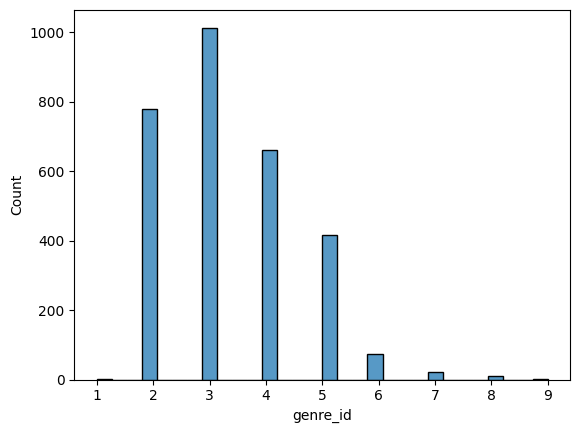

In [55]:
data_genre_links_dropped = data_genre_links.drop_duplicates(
    subset=["game_id", "mapped_genre"]
)

data_genre_link_dropped_compiled = data_genre_links_dropped.groupby("game_id").agg(
    {"genre_id": "count"})
sns.histplot(data_genre_compiled["genre_id"], bins=30)

In [56]:
ros_reduced = data_genre_links.shape[0] - data_genre_links_dropped.shape[0]
print(f"{ros_reduced} reduced rows after dropping duplicates")

3019 reduced rows after dropping duplicates


## Merge table with 3 prior genres

In [65]:
data_genre_links_dropped = data_genre_links_dropped.sort_values(["game_id", "priority"])
data_genre_links_dropped["genre_rank"] = (
    data_genre_links_dropped
    .groupby("game_id")
    .cumcount() + 1
)
data_genre_links_filtered = data_genre_links_dropped[
    data_genre_links_dropped["genre_rank"] <= 3]

data_genre_links_filtered = (
    data_genre_links_filtered
    .pivot(
        index="game_id",
        columns="genre_rank",
        values="mapped_genre"
    )
    .rename(columns={
        1: "primary_genre",
        2: "secondary_genre",
        3: "tertiary_genre"
    })
    .reset_index()
)
data_genre_links_filtered = data_genre_links_filtered.fillna("unknown")
data_genre_links_filtered.head()

genre_rank,game_id,primary_genre,secondary_genre,tertiary_genre
0,.hack//g.u. vol. 1//rebirth,rpg,unknown,unknown
1,.hack//infection part 1,rpg,unknown,unknown
2,.hack//mutation part 2,rpg,unknown,unknown
3,10 second ninja,action,platformer,unknown
4,1000 tiny claws,action,unknown,unknown


In [66]:
data_genre_links_filtered.shape  # type: ignore # noqa: F821

(2975, 4)

In [67]:
gold_game_catalog = gold_game_catalog.merge(
    data_genre_links_filtered,   # noqa: F821 # type: ignore
    on="game_id", 
    how="left")
gold_game_catalog.head()

,game_id,game_name,game_developer,game_rating,game_product_type,genre_id,current_price,currency,stock_status,meta_score,...,category_name,category_parent_id,primary_genre_x,secondary_genre_x,tertiary_genre_x,price_bucket,score_bucket,primary_genre_y,secondary_genre_y,tertiary_genre_y
0,the legend of zelda: ocarina of time,The Legend of Zelda: Ocarina of Time,nintendo,E,singleplayer,"action adventure, fantasy",91.99,EUR,in_stock,99,...,nintendo-64,nintendo,action,unknown,unknown,60+,masterpiece,action,unknown,unknown
1,super mario galaxy,Super Mario Galaxy,nintendo,E,singleplayer,"action, platformer, 3d",91.99,EUR,out_of_stock,97,...,wii,nintendo,action,platformer,unknown,60+,masterpiece,action,platformer,unknown
2,super mario galaxy 2,Super Mario Galaxy 2,nintendo ead tokyo,E,singleplayer,"action, platformer, 3d",91.99,EUR,in_stock,97,...,wii,nintendo,action,platformer,unknown,60+,masterpiece,action,platformer,unknown
3,metroid prime,Metroid Prime,retro studios,T,singleplayer,"action, shooter, first-person, sci-fi",89.99,EUR,out_of_stock,97,...,gamecube,nintendo,action,shooter,unknown,60+,masterpiece,action,shooter,unknown
4,super mario odyssey,Super Mario Odyssey,nintendo,E10+,singleplayer,"action, platformer, 3d",89.99,EUR,in_stock,97,...,switch,nintendo,action,platformer,unknown,60+,masterpiece,action,platformer,unknown


## Save Gold total table

In [ ]:
gold_game_catalog.to_parquet(DB_OUTPUT_GOLD / "gold_all_columns_game_catalog.parquet")

## Drop unnecessary columns

In [60]:
column_list = [
    "game_id",
    "game_name",
    "game_developer",
    "game_rating",
    "game_product_type",
    "genre_id",
    "current_price",
    "currency",
    "stock_status",
    "meta_score",
    "user_score",
    "category_name",
    "category_parent_id",
    "primary_genre",
    "secondary_genre",
    "tertiary_genre"]

gold_game_catalog = gold_game_catalog[column_list]

### Score and Price Buckets

In [61]:
def build_score_bucket(score):
    if pd.isna(score):
        return "unknown"

    if score >= 90:
        return "masterpiece"

    if score >= 80:
        return "excellent"

    if score >= 70:
        return "good"

    if score >= 60:
        return "average"

    return "poor"

def build_price_bucket(price: float) -> str:

    if pd.isna(price):
        return "unknown"

    if price == 0:
        return "free"

    if price < 10:
        return "<10"

    if price < 20:
        return "10-20"

    if price < 40:
        return "20-40"

    if price < 60:
        return "40-60"

    return "60+"

In [62]:
gold_game_catalog["price_bucket"] = (
    gold_game_catalog["current_price"]
    .apply(build_price_bucket)
)

gold_game_catalog["score_bucket"] = (
    gold_game_catalog["meta_score"]
    .apply(build_score_bucket)
)

## NaN Analysis

In [63]:
gold_game_catalog.isna().sum()

game_id               0
game_name             0
game_developer        0
game_rating           0
game_product_type     0
genre_id              0
current_price         0
currency              0
stock_status          0
meta_score            0
user_score            0
category_name         0
category_parent_id    0
primary_genre         0
secondary_genre       0
tertiary_genre        0
price_bucket          0
score_bucket          0
dtype: int64

## Save Dataset

In [64]:
gold_game_catalog.to_parquet(DB_OUTPUT_GOLD / "gold_game_catalog.parquet")